# Libraries

In [1]:
import warnings
from pathlib import Path

from tqdm import tqdm

from matplotlib import pyplot as plt
import numpy as np
import seaborn as sn
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from sklearn.inspection import permutation_importance
import xgboost
import shap
from boruta import BorutaPy
import neurokit2 as nk
from helper_code import *

## Settings

In [251]:
%load_ext autoreload

%autoreload 2

# Control figure size
%matplotlib inline
figsize=(14, 4)

warnings.filterwarnings('ignore')

# Random seed
SEED = 42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Detection of Chagas Disease from the ECG: PhysioNet Challenge 2025

## Introduction

Chagas disease is a potentially life-threatening illness caused by the protozoan parasite Trypanosoma cruzi (T. cruzi). It is found mainly in endemic areas of 21 countries in Latin America, where it is mostly transmitted to humans by the feces of triatomine bugs known as "kissing bugs". The disease is also known as American trypanosomiasis.

The disease is named after the Brazilian physician Carlos Chagas, who discovered it in 1909. The disease can be acute or chronic, but the chronic form is the most common and usually develops 10 to 30 years after the initial infection. The acute phase of the disease is usually mild or asymptomatic, but the chronic phase can cause serious heart and digestive problems.

The disease is diagnosed by detecting the parasite in the blood or by serological tests. The electrocardiogram (ECG) is an important tool for diagnosing Chagas disease, as it can show changes in the heart's electrical activity that are characteristic of the disease.

The goal of this challenge is to develop algorithms that can automatically detect Chagas disease from ECG signals. The challenge is based on a dataset of ECG signals from patients with Chagas disease and healthy controls. The dataset is provided by the PhysioNet Challenge 2025.

## Dataset

We will first load all the exams from the dataset and then we will load the labels for each exam.

In [3]:
exams = pd.read_csv('code15_hdf5/exams.csv')
all_labels = pd.read_csv('code15_hdf5/code15_chagas_labels.csv')

The `find_records` function will be used to find all the exams in a given folder by recursively searching for all the files with the `.hea` extension. It will provide a list of all the exams ids in the folder.

In [20]:
train_data_folder = Path("code15_wfdb")

train_records = find_records(train_data_folder.absolute().__str__())

Then we can slice the original dataset to get only the exams that are in the list of exams ids that we found (thus producing a new dataset with only the exams that we have locally). Moreover, we will load the labels for each exam by merging the labels dataset with the exams dataset on the `exam_id` column.

In [21]:
df = exams[exams['exam_id'].isin([int(x) for x in train_records])].merge(all_labels, on='exam_id')

Since our dataset is very unbalanced (only around 2% of the exams are positive for Chagas disease), we will extract a sample of the dataset for the negative class. This will allow us to train our models on a more balanced dataset while using all the positive exams. The random sampling produces a sample of the negative class that is representative of the original dataset since the original dataset was already sampled in a stratified way producing 17 different datasets (each with the same proportion of positive and negative exams).

In [45]:
n_positive = df[df['chagas'] == True].shape[0]
balanced_df = pd.concat([df[df['chagas'] == False].sample(n=n_positive, random_state=SEED), df[df['chagas'] == True]])
balanced_records_list = balanced_df.exam_id.values.tolist()

Now we can extract the number of positive and negative exams in the sample.

In [23]:
print(f"Number of positive samples: {n_positive}")
print(f"Number of negative samples: {len(balanced_records_list) - n_positive}")

Number of positive samples: 6559
Number of negative samples: 6559


We can also get the record of a patient combined with the demographic information and plot the ECG signal.

In [85]:
def get_patient_data(record_id: int):
    record = f"{str(train_data_folder.absolute())}{os.sep}{record_id}"
    header = load_header(record)
    signals, fields = load_signals(record)
    frequency = get_sampling_frequency(header)
    label = get_label(header)

    return record, record_id, label, signals, frequency

In [89]:
record, exam_id, label, signals, frequency = get_patient_data(record_id=balanced_records_list[1])
print(f"Record: {record}, Exam ID: {exam_id}, Label: {label}")
exams[exams['exam_id'] == int(exam_id)]

Record: /home/matteo/Documenti/VSCODE/ECG-Chagas/code15_wfdb/158912, Exam ID: 158912, Label: 0


,exam_id,age,is_male,nn_predicted_age,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,death,timey,normal_ecg,trace_file
98293,158912,38,False,31.159468,False,False,False,False,False,False,158554,NaN,NaN,True,exams_part0.hdf5


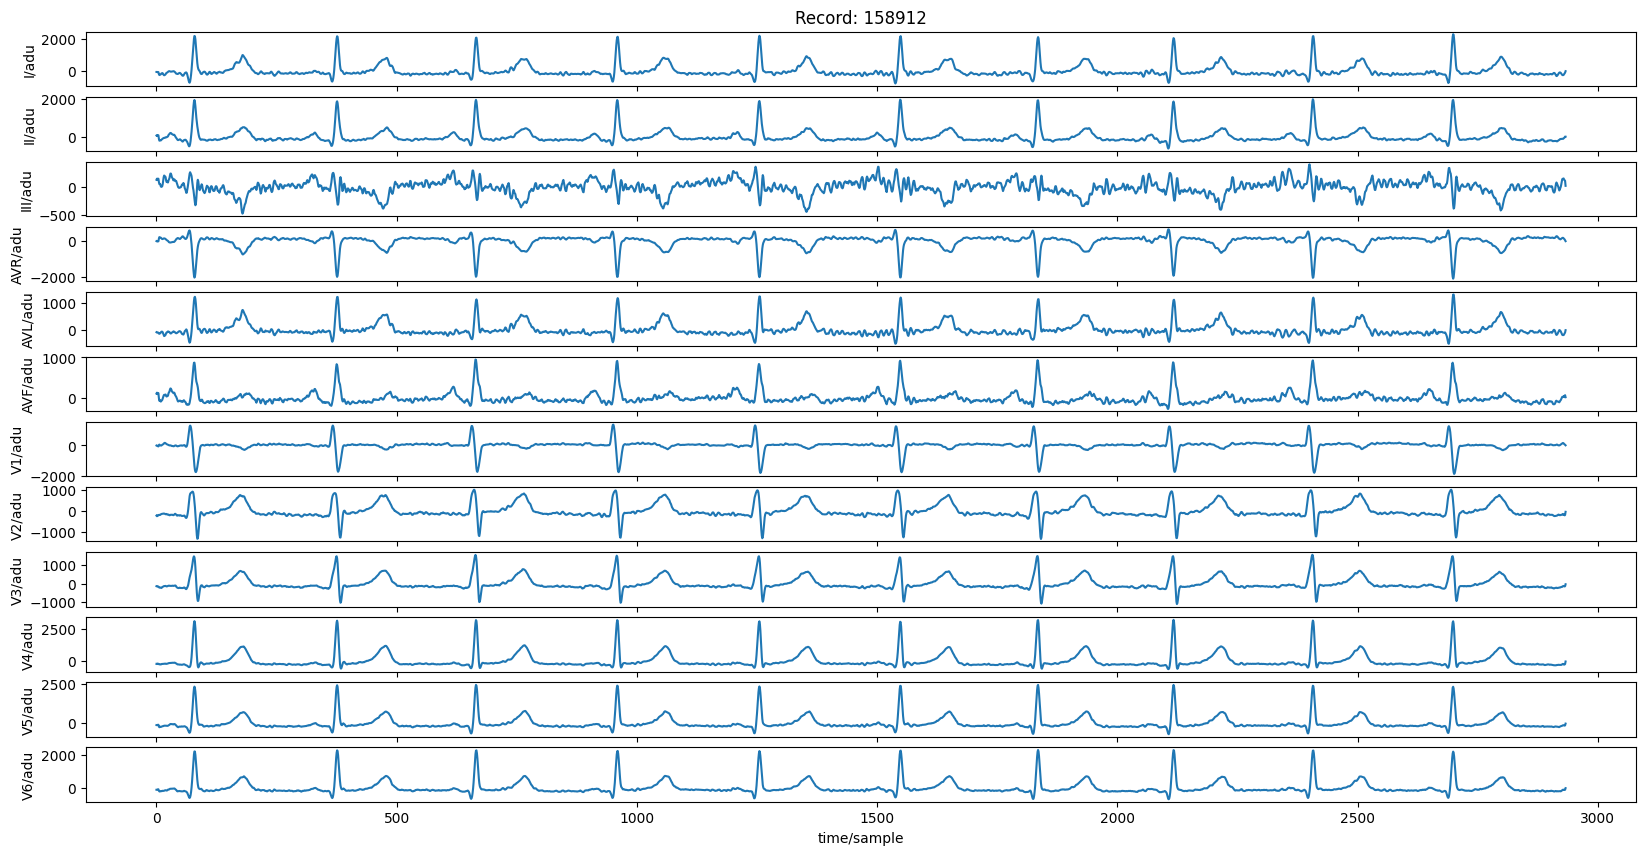

In [90]:
wfdb.plot_wfdb(record=wfdb.rdrecord(record, physical=False), figsize=(20, 10), time_units='samples')

---

The `my_processing` function will be used to process the ECG signal. It is based on the custom pipeline adapation of NeuroKit2's `ecg_process` function.

The function will take the ECG signal and the sampling rate as input and will return a dictionary with the processed ECG signal and the features extracted from it.

The function will first filter the ECG signal using a bandpass filter. Then it will detect the R-peaks using the `ecg_peaks` function and extract all the waves information using the `ecg_delineate` function.

In [27]:
# Define a new function
def my_processing(ecg_signals: np.ndarray, channel: int, frequency: int):
    # Do processing
    ecg_cleaned = nk.ecg_clean(ecg_signals[:, channel], sampling_rate=frequency)
    peaks, info = nk.ecg_peaks(ecg_cleaned, sampling_rate=frequency)
    waves, waves_signals = nk.ecg_delineate(ecg_cleaned, info, sampling_rate=frequency, method="dwt", check=True, show=False, show_type='all')

    phases = nk.ecg_phase(ecg_cleaned, peaks, sampling_rate=frequency, delineate_info=waves_signals)
    rate = nk.ecg_rate(info, sampling_rate=frequency, desired_length=len(ecg_cleaned))
    quality = nk.ecg_quality(ecg_cleaned, sampling_rate=frequency)

    # Prepare output
    signals = pd.DataFrame({"ECG_Raw": ecg_signals[:, channel],
                            "ECG_Clean": ecg_cleaned,
                            "ECG_Rate": rate,
                            "ECG_Quality": quality})
    signals = pd.concat([signals, peaks, waves, phases], axis=1)

    # Create info dict
    info = info
    info["sampling_rate"] = frequency

    waves_signals['ECG_R_Peaks'] = info['ECG_R_Peaks']
    
    return signals, info, waves_signals

During the pre-processing phase we spotted a couple of issues with the ECG signals. Some of the signals were very noisy and the R-peaks detection was not accurate. Moreover, the extraction of the P, Q, S and T waves was not accurate for some of the signals. 

Our idea was then to check for the order of presence of the waves in the ECG signal. We will check if the P wave is present before the Q wave, if the Q wave is present before the R wave, if the R wave is present before the S wave and if the S wave is present before the T wave. If the order is not respected, we will discard the ECG signal.

Given a record of 10 seconds, we will check if the order of the waves is respected in all the R-peaks. Whenever the order is not respected, we will discard the specific R-peak and the corresponding waves. At the end, we will have a list of R-peaks that respect the order of the waves thus producing a clean ECG signal.

The implementation uses a boolean mask to check if the order of the waves is respected. The mask is then used to filter the R-peaks and the corresponding waves.

In [28]:
def check_interval(waves_signals):
    df_waves = pd.DataFrame(waves_signals)
    df_waves.drop(columns=['ECG_R_Onsets', 'ECG_R_Offsets'], inplace=True)
    correct_indices = ['ECG_P_Onsets', 'ECG_P_Peaks', 'ECG_P_Offsets',
       'ECG_Q_Peaks', 'ECG_R_Peaks', 'ECG_S_Peaks', 'ECG_T_Onsets', 'ECG_T_Peaks', 'ECG_T_Offsets', ]
    rows = df_waves.shape[0]
    mask = np.zeros(rows)
    for i in range(1, rows):
        start_interval = df_waves.loc[i-1, 'ECG_R_Peaks']
        end_interval = df_waves.loc[i, 'ECG_R_Peaks']
        sliced_df = df_waves[df_waves.isin([start_interval, end_interval]).any(axis=1)]
        # if the sliced df has no missing values, then the interval is correct and the mask should be 1
        first_condition = sliced_df[correct_indices].isnull().sum().sum() == 0
        second_condition = correct_indices == sliced_df.iloc[0].sort_values(ascending=True).index.tolist()
        if first_condition and second_condition:
            mask[i] = 1
    return df_waves[mask == 1]

After extracting all the meaningful waves, we will extract the features from the ECG signal. We will extract the P wave duration, PR interval, PR segment length, QRS duration, QT interval, and ST segment length.

In [29]:
def ecg_signal_features(row, frequency: int = 400):
    ECG_P_Peaks, ECG_P_Onsets, ECG_P_Offsets, ECG_Q_Peaks, ECG_S_Peaks, ECG_T_Peaks, ECG_T_Onsets, ECG_T_Offsets, ECG_R_Peaks = row
    # Compute the P wave duration
    P_wave_duration = (ECG_P_Offsets - ECG_P_Onsets) / frequency
    # Compute the PR interval
    PR_interval = (ECG_Q_Peaks - ECG_P_Onsets) / frequency
    # Compute the PR segment
    PR_segment = (ECG_Q_Peaks - ECG_P_Offsets) / frequency
    # Compute the QRS duration
    QRS_duration = (ECG_S_Peaks - ECG_Q_Peaks) / frequency
    # Compute the QT interval
    QT_interval = (ECG_T_Offsets - ECG_Q_Peaks) / frequency
    # Compute the ST segment
    ST_segment = (ECG_T_Onsets - ECG_S_Peaks) / frequency

    return {
        "P_wave_duration": P_wave_duration,
        "PR_interval": PR_interval,
        "PR_segment": PR_segment,
        "QRS_duration": QRS_duration,
        "QT_interval": QT_interval,
        "ST_segment": ST_segment
    }

To better highlight potential cardiac abnormalities, we will also extract the ST slope by calculating the slope of the ST segment. The ST slope is an important feature that can help in the diagnosis of cardiac diseases.

In [30]:
def st_slope(signal_df, s_peak, t_onset):
    return (signal_df.iloc[t_onset]['ECG_Clean'] - signal_df.iloc[s_peak]['ECG_Clean']) / (t_onset - s_peak)

Then, for each of the record ids, we will extract the signals and the frequencies. We will process the signals and extract the cleaned signals + P, R, Q, S, T waves. We will check that the waves have the correct order (P -> Q -> R -> S -> T). We will extract the features from the signals (P wave duration, PR interval, QRS complex duration, QT interval, RR interval). We will extract the ST slope.

Finally, we will create a new dataset with the features extracted from the ECG signals. We will merge this dataset with the labels dataset to get the labels for each exam.

A summary of the steps is provided below:
1. iterate over the record ids and extract the signals and frequencies
2. process the signals and extract the cleaned signals + P, R, Q, S, T waves
3. check that the waves have the correct order (P -> Q -> R -> S -> T)
4. extract the features from the signals (P wave duration, PR interval, QRS complex duration, QT interval, RR interval)
5. extract the ST slope

In [34]:
error_records = []
channel = 1
hand_features = pd.DataFrame()
for record_id in tqdm(balanced_records_list):
    record = f"{str(train_data_folder.absolute())}{os.sep}{record_id}"
    header = load_header(record)
    signals, fields = load_signals(record)
    frequency = get_sampling_frequency(header)

    try:
        processed_signals, _, waves_signals = my_processing(signals, channel, frequency)
    except:
        error_records.append(record_id)
        continue
    correct_waves = check_interval(waves_signals)
    if correct_waves.shape[0] == 0:
        error_records.append(record_id)
        continue
    correct_waves[["P_wave_duration","PR_interval","PR_segment","QRS_duration","QT_interval","ST_segment"]] = correct_waves.apply(lambda x: ecg_signal_features(x, frequency), axis=1, result_type='expand')
    correct_waves['ST_slope'] = correct_waves.apply(lambda x: st_slope(processed_signals, int(x['ECG_S_Peaks']), int(x['ECG_T_Onsets'])), axis=1)
    correct_waves['exam_id'] = record_id
    hand_features = pd.concat([hand_features, correct_waves])

  0%|          | 0/13118 [00:00<?, ?it/s]

100%|██████████| 13118/13118 [50:42<00:00,  4.31it/s] 


At the end of the process, we have some records in which the algorithm did not extract the waves correctly. This is mainly due to the fact that the lead channel from which we are trying to extract the waves is not the best one. Following insights from the ECG experts, the signal which is usually the best for extracting the waves is the DII channel. In some cases, the DII channel is affected by noise and the waves are not extracted correctly. In those cases, we will try to extract the waves from other channels and see if we can get better results.

In [93]:
for error_record_id in tqdm(error_records):
    for channel in range(0,12):
        if channel != 1:
            record = f"{str(train_data_folder.absolute())}{os.sep}{error_record_id}"
            header = load_header(record)
            signals, fields = load_signals(record)
            frequency = get_sampling_frequency(header)

            try:
                processed_signals, _, waves_signals = my_processing(signals, channel, frequency)
            except:
                continue
            correct_waves = check_interval(waves_signals)
            if correct_waves.shape[0] == 0:
                continue
            correct_waves[["P_wave_duration","PR_interval","PR_segment","QRS_duration","QT_interval","ST_segment"]] = correct_waves.apply(lambda x: ecg_signal_features(x, frequency), axis=1, result_type='expand')
            correct_waves['ST_slope'] = correct_waves.apply(lambda x: st_slope(processed_signals, int(x['ECG_S_Peaks']), int(x['ECG_T_Onsets'])), axis=1)
            correct_waves['exam_id'] = error_record_id
            hand_features = pd.concat([hand_features, correct_waves])
            break

100%|██████████| 649/649 [03:30<00:00,  3.08it/s]


In [97]:
# save correct waves dataframe to a csv file
hand_features.to_csv('hand_features.csv', index=False)

# save error records to a csv file
pd.DataFrame(error_records).to_csv('error_records.csv', index=False)

---

Here we will merge the features computed from the ECG signals with the demographic information and the labels for each exam.

In [184]:
test = pd.read_csv('hand_features.csv')

In [185]:
what_i_want = test.iloc[:, 9:].groupby('exam_id').agg(['mean', 'std', 'min', 'max']).reset_index()
what_i_want.columns = ['_'.join(col).strip() for col in what_i_want.columns.values]
what_i_want.rename(columns={'exam_id_': 'exam_id'}, inplace=True)
what_i_want = what_i_want.merge(balanced_df, on='exam_id')
what_i_want.drop(columns=['patient_id_x', 'patient_id_y', 'nn_predicted_age', '1dAVb', 'RBBB',
       'LBBB', 'SB', 'ST', 'AF', 'death', 'timey', 'normal_ecg',
       'trace_file'], inplace=True)

In [186]:
balanced_df.chagas.value_counts()

chagas
False    6559
True     6559
Name: count, dtype: int64

In [187]:
what_i_want.chagas.value_counts()

chagas
True     6551
False    6541
Name: count, dtype: int64

In [188]:
to_be_dropped = what_i_want[what_i_want['ST_slope_mean'].isna()].exam_id.values.tolist()

In [ ]:
what_i_want = what_i_want[~what_i_want['exam_id'].isin(to_be_dropped)].fillna(value=0)

---

# EDA

In [190]:
df = what_i_want

In [194]:
df.drop('exam_id', axis=1, inplace=True)

In [195]:
df.head()

,P_wave_duration_mean,P_wave_duration_std,P_wave_duration_min,P_wave_duration_max,PR_interval_mean,PR_interval_std,PR_interval_min,PR_interval_max,PR_segment_mean,PR_segment_std,...,ST_segment_std,ST_segment_min,ST_segment_max,ST_slope_mean,ST_slope_std,ST_slope_min,ST_slope_max,age,is_male,chagas
0,0.072500,0.016105,0.0500,0.1050,0.173611,0.036936,0.1075,0.2250,0.101111,0.033474,...,0.109450,0.0050,0.245,0.011122,0.007091,0.005171,0.022582,77,True,False
1,0.107500,0.020616,0.0700,0.1250,0.195417,0.036892,0.1400,0.2375,0.087917,0.044705,...,0.014053,0.1475,0.190,0.004751,0.000823,0.003540,0.006099,81,False,False
2,0.088750,0.001768,0.0875,0.0900,0.140000,0.000000,0.1400,0.1400,0.051250,0.001768,...,0.007071,0.1050,0.115,0.003746,0.000336,0.003508,0.003984,23,True,False
3,0.122000,0.004108,0.1175,0.1275,0.167000,0.003260,0.1625,0.1700,0.045000,0.002500,...,0.005969,0.1050,0.120,0.005217,0.000209,0.004959,0.005515,30,False,False
4,0.130417,0.006785,0.1225,0.1400,0.190833,0.013934,0.1650,0.2050,0.060417,0.016311,...,0.009800,0.1375,0.165,0.005217,0.000317,0.004715,0.005631,65,False,False


In [196]:
df.describe()

,P_wave_duration_mean,P_wave_duration_std,P_wave_duration_min,P_wave_duration_max,PR_interval_mean,PR_interval_std,PR_interval_min,PR_interval_max,PR_segment_mean,PR_segment_std,...,QT_interval_max,ST_segment_mean,ST_segment_std,ST_segment_min,ST_segment_max,ST_slope_mean,ST_slope_std,ST_slope_min,ST_slope_max,age
count,13085.000000,13085.000000,13085.000000,13085.000000,13085.000000,13085.000000,13085.000000,13085.000000,13085.000000,13085.000000,...,13085.000000,13085.000000,13085.000000,13085.000000,13085.000000,13085.000000,13085.000000,13085.000000,13085.000000,13085.000000
mean,0.093815,0.016566,0.073501,0.115522,0.145800,0.022438,0.117756,0.174135,0.051985,0.022536,...,0.408829,0.130694,0.035574,0.084254,0.171703,0.007179,0.002079,0.004880,0.010012,56.730990
std,0.023969,0.013382,0.028201,0.029242,0.036984,0.022388,0.043283,0.050566,0.036601,0.021530,...,0.076978,0.065850,0.035506,0.084513,0.067775,0.008711,0.004666,0.007771,0.013066,17.936637
min,0.017500,0.000000,0.010000,0.017500,-0.092500,0.000000,-0.147500,-0.092500,-0.165000,0.000000,...,0.130000,-0.405000,0.000000,-0.542500,-0.405000,-0.022610,0.000000,-0.134711,-0.017035,17.000000
25%,0.078500,0.006292,0.047500,0.102500,0.126500,0.008122,0.097500,0.147500,0.029000,0.007826,...,0.372500,0.098750,0.011143,0.017500,0.140000,0.003042,0.000524,0.001599,0.004286,43.000000
50%,0.096875,0.013509,0.072500,0.115000,0.142500,0.016623,0.117500,0.165000,0.044750,0.016808,...,0.410000,0.137917,0.023485,0.095000,0.175000,0.004775,0.000938,0.003141,0.006482,58.000000
75%,0.109722,0.023910,0.095000,0.130000,0.160357,0.028267,0.137500,0.190000,0.066000,0.030187,...,0.450000,0.172917,0.047189,0.145000,0.212500,0.008483,0.001979,0.006126,0.011347,72.000000
max,0.332500,0.205715,0.332500,0.467500,0.875000,0.279318,0.875000,0.875000,0.542500,0.272236,...,1.197500,0.765000,0.411890,0.765000,0.765000,0.349348,0.190491,0.349348,0.428148,94.000000


In [197]:
df.chagas.value_counts(normalize=True)

chagas
True     0.500344
False    0.499656
Name: proportion, dtype: float64

Cast the boolean columns to integers.

In [198]:
df['is_male'] = df['is_male'].astype(int)
df['chagas'] = df['chagas'].astype(int)

Exctract the numerical and categorical columns.

In [204]:
num_cols = [c for c in df.columns[:-1] if df[c].nunique() > 2]
cat_cols = [c for c in df.columns[:-1] if df[c].nunique() == 2]
print(f'Numeric: {num_cols}\nTotal: {len(num_cols)}')
print(f'Categorical: {cat_cols}\nTotal: {len(cat_cols)}')

Numeric: ['P_wave_duration_mean', 'P_wave_duration_std', 'P_wave_duration_min', 'P_wave_duration_max', 'PR_interval_mean', 'PR_interval_std', 'PR_interval_min', 'PR_interval_max', 'PR_segment_mean', 'PR_segment_std', 'PR_segment_min', 'PR_segment_max', 'QRS_duration_mean', 'QRS_duration_std', 'QRS_duration_min', 'QRS_duration_max', 'QT_interval_mean', 'QT_interval_std', 'QT_interval_min', 'QT_interval_max', 'ST_segment_mean', 'ST_segment_std', 'ST_segment_min', 'ST_segment_max', 'ST_slope_mean', 'ST_slope_std', 'ST_slope_min', 'ST_slope_max', 'age']
Total: 29
Categorical: ['is_male']
Total: 1


Plot the distribution of the numerical columns.

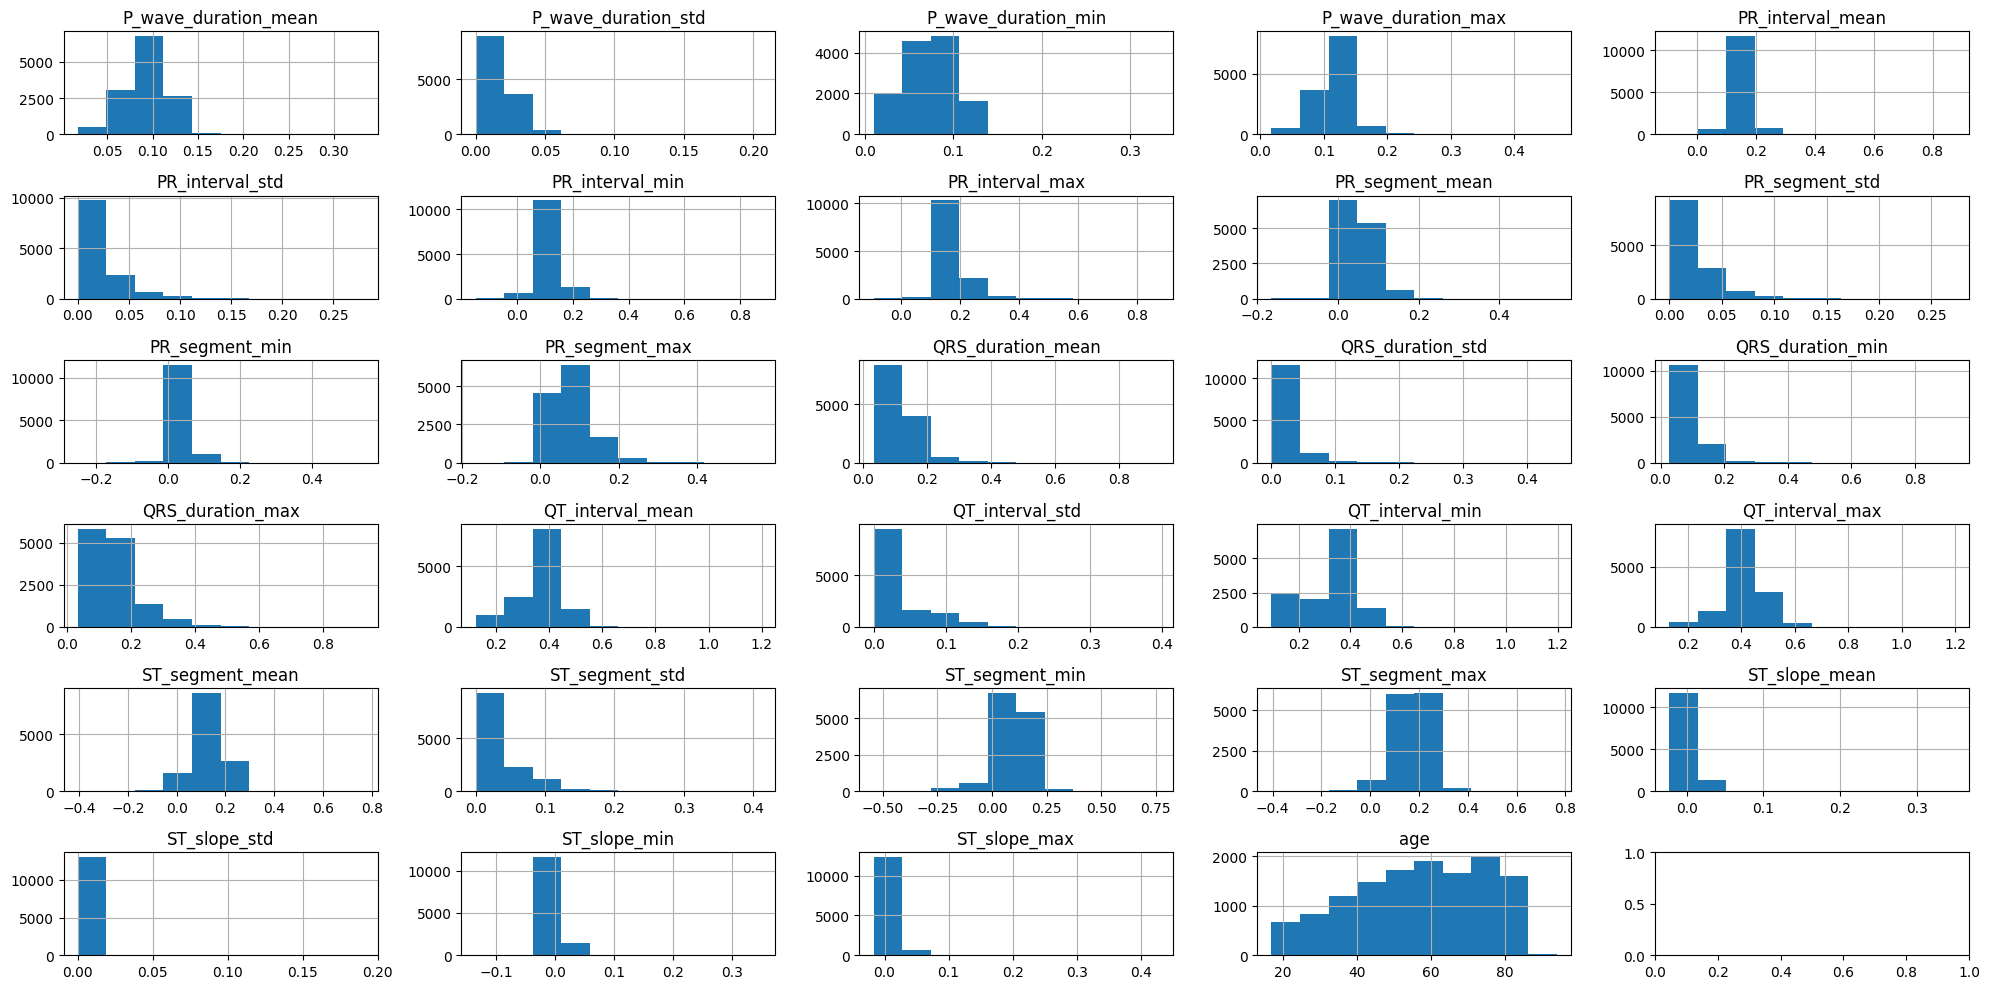

In [205]:
_, axes = plt.subplots(nrows=6, ncols=int(np.ceil(len(num_cols)//5)), figsize=(20, 10))
for ax, cname in zip(axes.ravel(), num_cols):
    df.hist(cname, ax=ax)
plt.tight_layout()
plt.show()

Plot the distribution of the categorical columns.

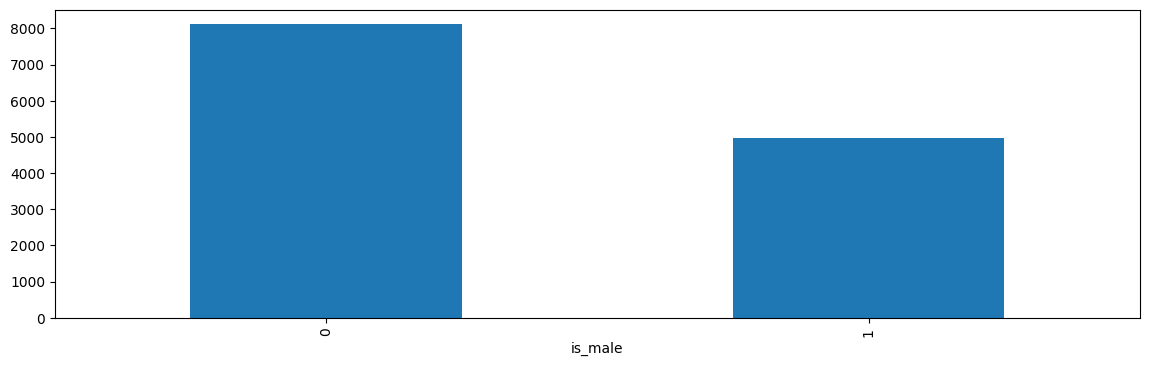

In [206]:
_, axes = plt.subplots(nrows=1, ncols=1, figsize=figsize)
for cname in cat_cols:
    df[cname].value_counts().plot(kind='bar', ax=axes)

Plot the distribution of the target variable.

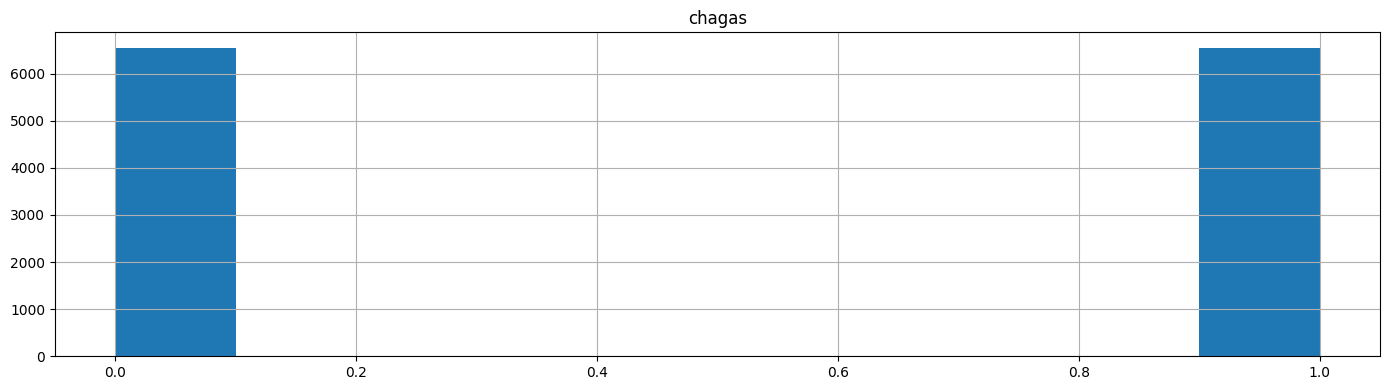

In [207]:
df.hist('chagas', figsize=figsize)
plt.tight_layout()

Plot the distribution of the target variable conditioned on the categorical columns.

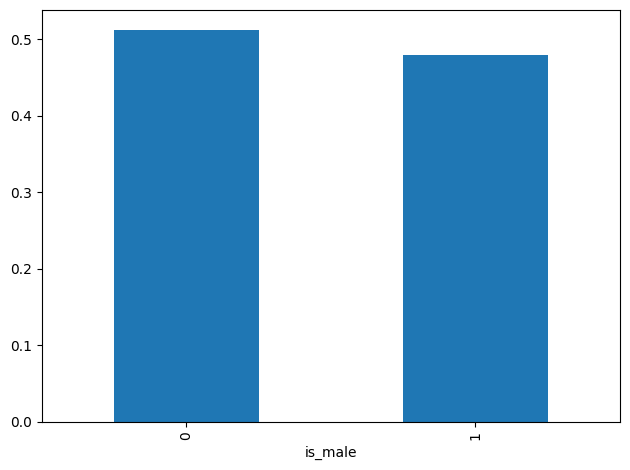

In [208]:
df.groupby('is_male')['chagas'].mean().plot.bar()
plt.tight_layout()

Plot the distribution of the numerical columns conditioned by the target variable.

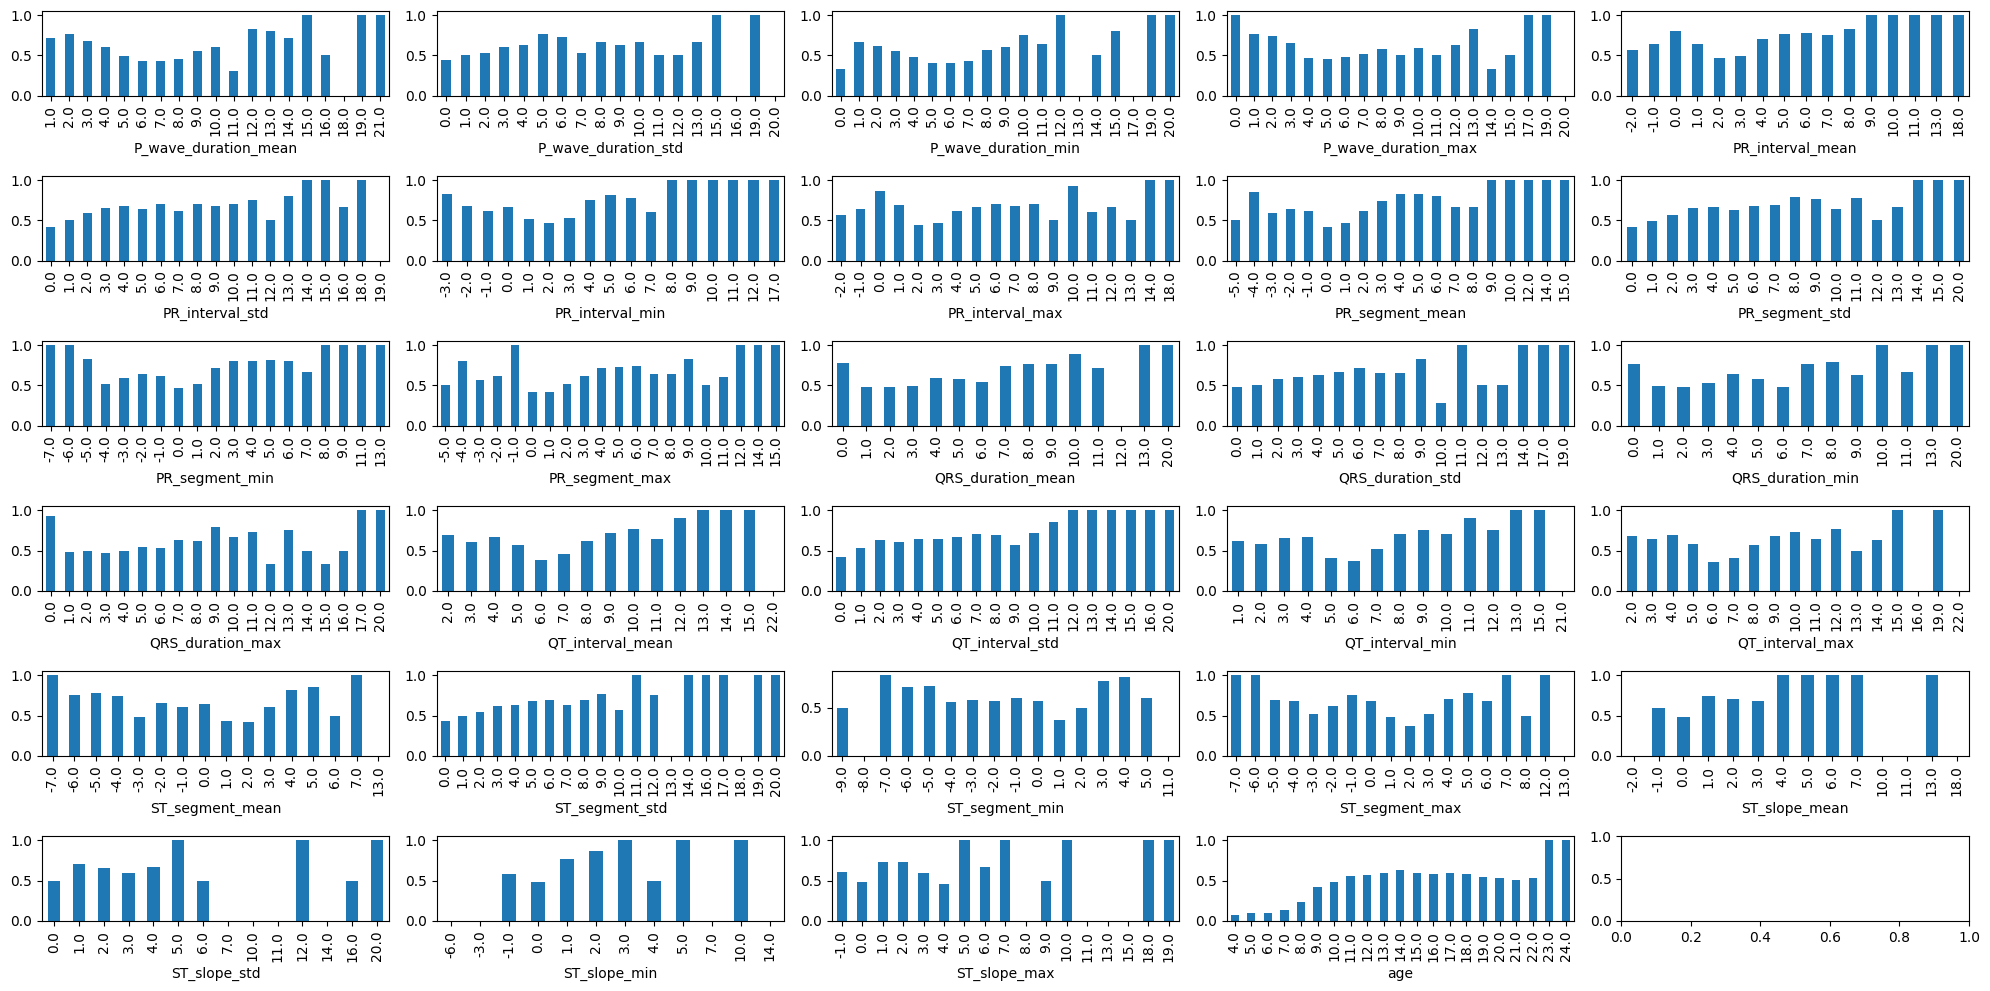

In [209]:
_, axes = plt.subplots(nrows=6, ncols=int(np.ceil(len(num_cols)//5)), figsize=(20,10))
for ax, cname in zip(axes.ravel(), num_cols):
    bin_size = (df[cname].max() - df[cname].min()) / 20
    df['chagas'].groupby(df[cname] // bin_size).mean().plot.bar(ax=ax)
plt.tight_layout()

Plot the correlation matrix of the numerical columns.

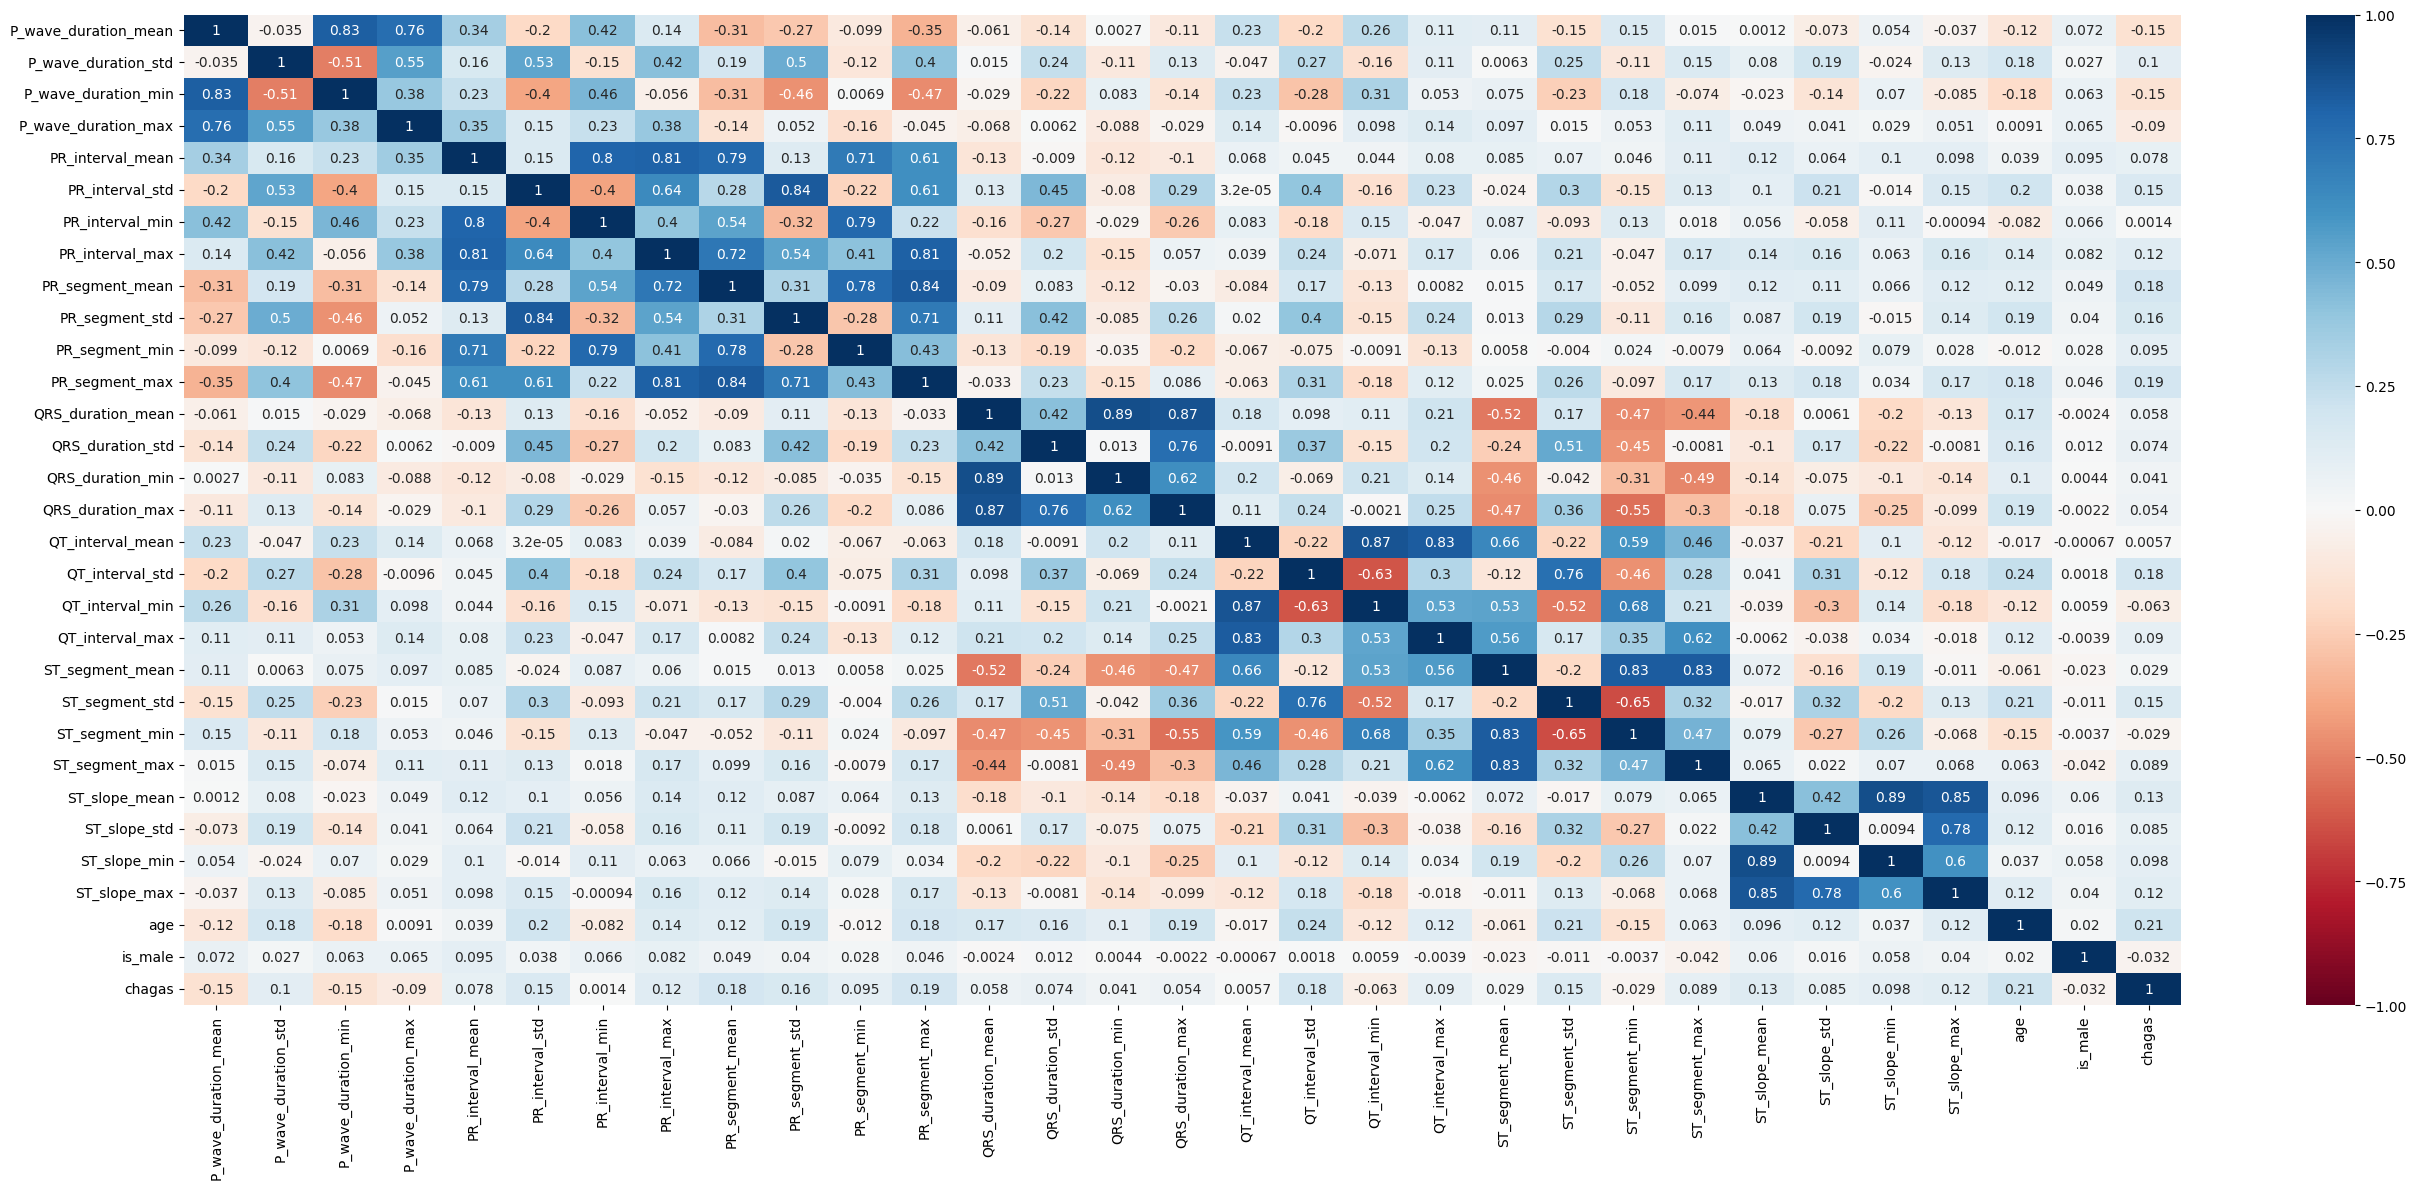

In [236]:
plt.figure(figsize=(27,12))
sn.heatmap(df.corr(method='pearson'), annot=True, vmin=-1, vmax=1, cmap='RdBu')
plt.tight_layout()

Split the data into training and testing sets. Shuffle the data and stratify the target variable.

Apply the StandardScaler to the numerical columns.

In [237]:
X, y = df.drop(columns='chagas', axis=1), df['chagas']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y, shuffle=True)
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Logistic Regression

In [238]:
base_est = LogisticRegression(penalty='l1', solver='saga',)
param_grid={'C': 1. / np.linspace(1e-1, 1e4, 100)}
gscv = GridSearchCV(base_est, param_grid=param_grid, scoring='roc_auc')
gscv.fit(X_train, y_train)
lr, lr_params = gscv.best_estimator_, gscv.best_params_

In [239]:
lr_score_cv, lr_score_test = gscv.best_score_, roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
print(f'AUC score for C={lr_params["C"]:.2f}: {lr_score_cv:.2f} (cross-validation), {lr_score_test:.2f} (test)')

AUC score for C=10.00: 0.72 (cross-validation), 0.71 (test)


0.6303630363036303
Confusion matrix:
[[0.3656859  0.13412304]
 [0.20825373 0.29193733]]


<Axes: >

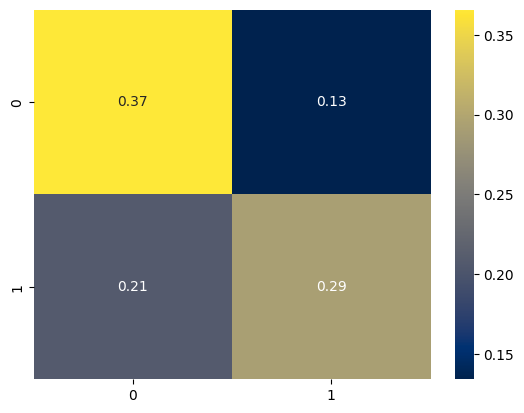

In [240]:
cm = confusion_matrix(y_test, lr.predict(X_test), labels=[0, 1], normalize='all')
print(f1_score(y_test, lr.predict(X_test)))
print(f'Confusion matrix:\n{cm}')
sn.heatmap(cm, annot=True, cmap='cividis')

In [241]:
pd.Series( lr.predict_proba(X_test)[:, 1]).describe()

count    2617.000000
mean        0.500610
std         0.178635
min         0.120788
25%         0.364665
50%         0.461772
75%         0.615304
max         0.999975
dtype: float64

<Axes: >

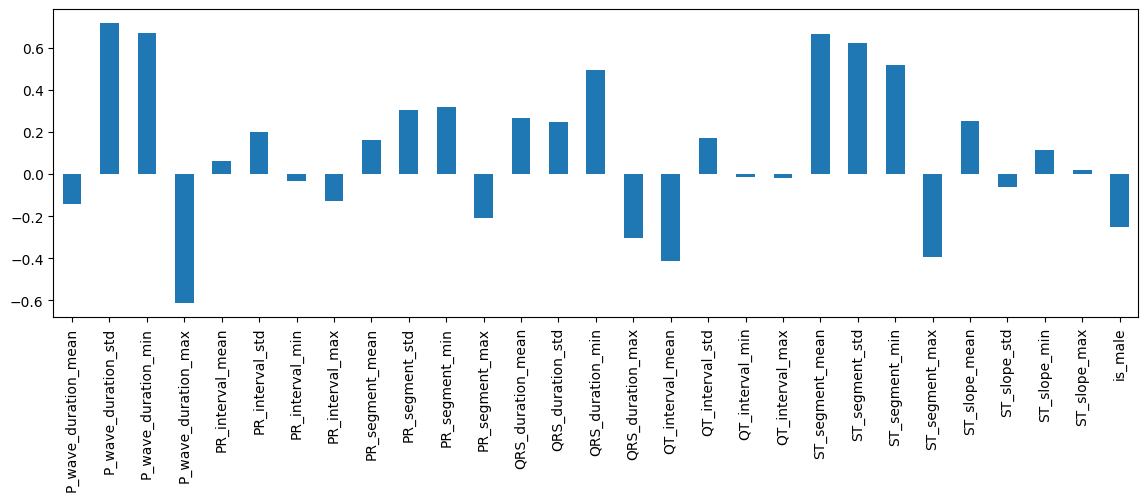

In [242]:
lr_coefs = pd.Series(index=X.columns, data=lr.coef_[0])
lr_coefs.plot(kind='bar', figsize=figsize)

# XGBoost

In [243]:
base_est = xgboost.XGBClassifier(tree_method='hist', importance_type='total_gain')
param_grid={'max_depth': [2, 3, 4], 'n_estimators': list(range(20, 41, 5)), 'reg_lambda': np.linspace(0, 500, 6)}
gscv = GridSearchCV(base_est, param_grid=param_grid)
gscv.fit(X_train, y_train)
xbm, xbm_params = gscv.best_estimator_, gscv.best_params_

<Axes: >

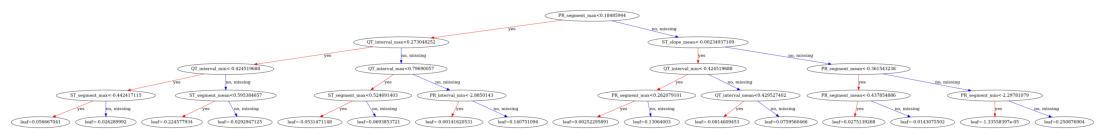

In [244]:
plt.figure(figsize=figsize)
xgboost.plot_tree(xbm, ax=plt.gca(), num_trees=0)

In [245]:
xbm_score_cv, xbm_score_test = gscv.best_score_, roc_auc_score(y_test, xbm.predict(X_test))
print(f'AUC score for {xbm_params}: {xbm_score_cv:.2f} (cross-val.), {xbm_score_test:.2f} (test)')

AUC score for {'max_depth': 4, 'n_estimators': 40, 'reg_lambda': np.float64(100.0)}: 0.67 (cross-val.), 0.65 (test)


<Axes: >

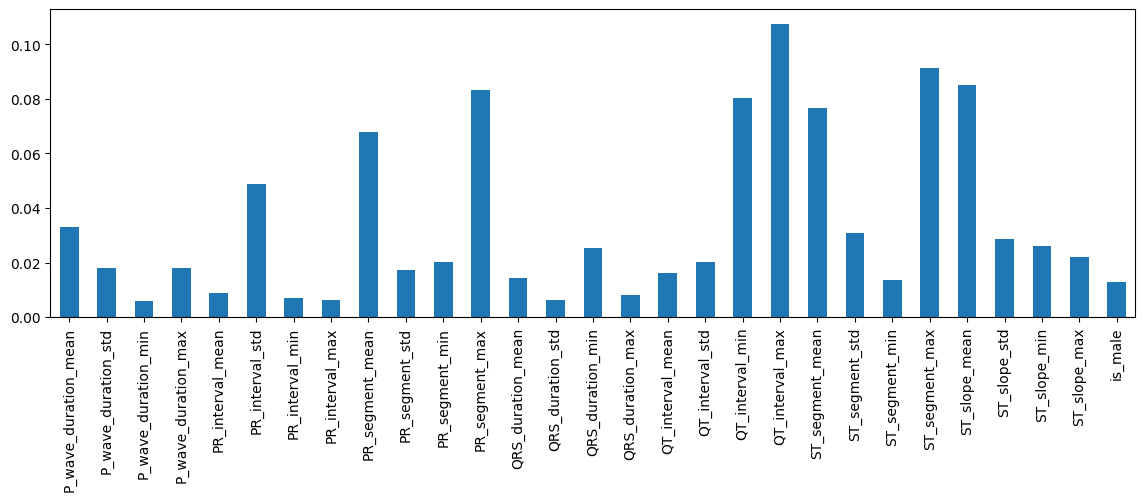

In [246]:
xbm_imp = pd.Series(index=X.columns, data=xbm.feature_importances_)
xbm_imp.plot(kind='bar', figsize=figsize)

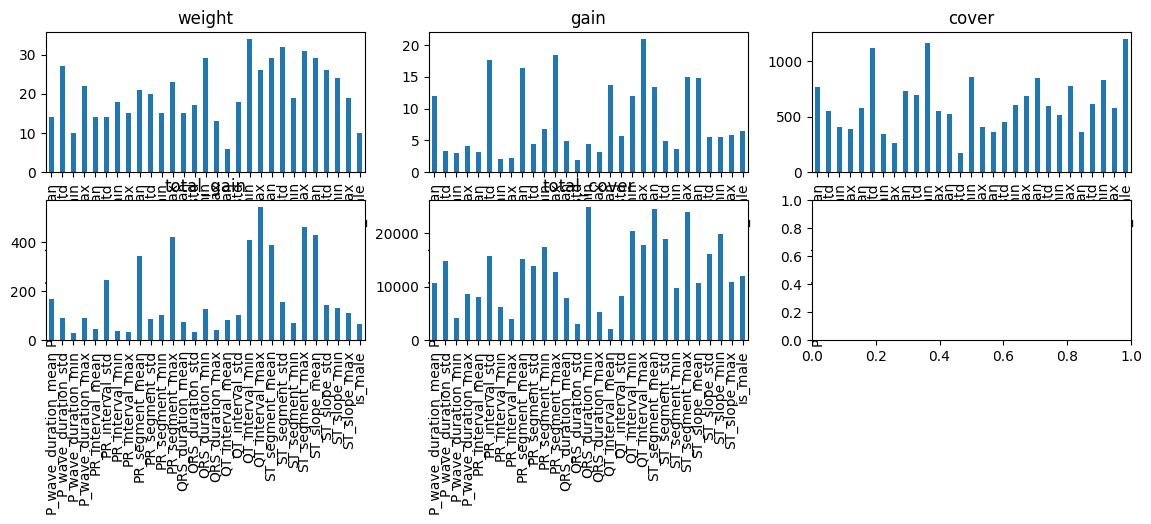

In [247]:
_, axes = plt.subplots(nrows=2, ncols=3, figsize=figsize)
for ax, imp_type in zip(axes.ravel(), ['weight', 'gain', 'cover', 'total_gain', 'total_cover']):
    pd.Series(xbm.get_booster().get_score(importance_type=imp_type)).plot.bar(ax=ax, title=imp_type)
plt.tight_layout()

# Permutation Importance

2025-01-28 18:24:33.537265: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738085073.661991  104129 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738085073.698697  104129 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-28 18:24:34.011720: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


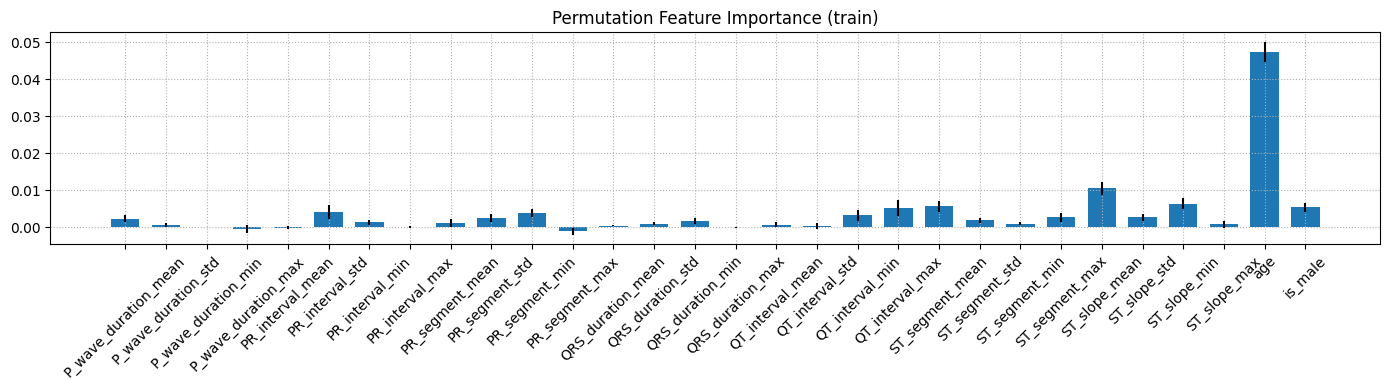

In [225]:
import util

r_train = permutation_importance(xbm, X_train, y_train, n_repeats=30, random_state=SEED)
xbm_p_imp = pd.Series(index=X.columns, data=r_train.importances_mean)
util.plot_bars(xbm_p_imp, figsize=figsize, std=r_train.importances_std, title='Permutation Feature Importance (train)')

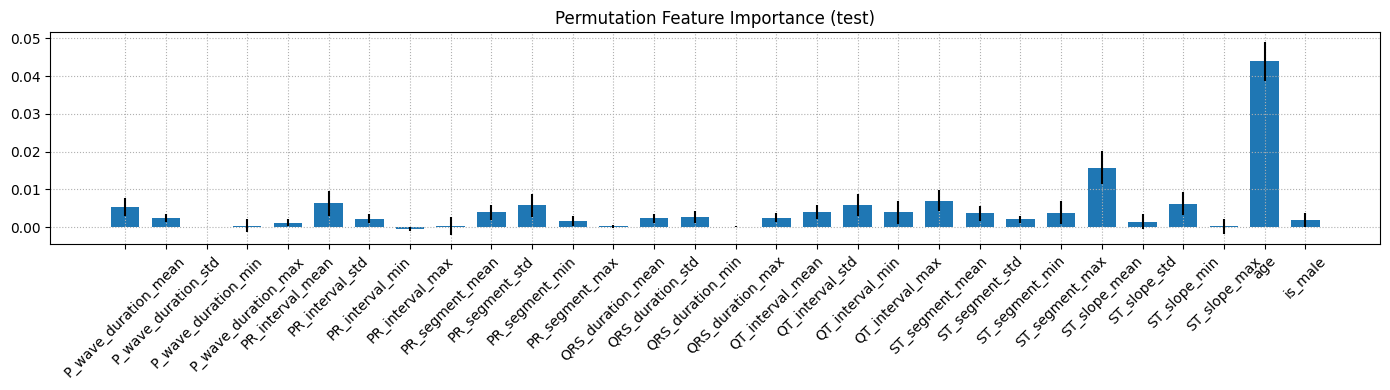

In [226]:
r_test = permutation_importance(xbm, X_test, y_test, n_repeats=30, random_state=SEED)
xbm_p_imp = pd.Series(index=X.columns, data=r_test.importances_mean)
util.plot_bars(xbm_p_imp, figsize=figsize, std=r_test.importances_std, title='Permutation Feature Importance (test)')

# SHAP Values

In [ ]:
f = lambda x: xbm.predict_proba(x)[:,1]
explainer = shap.KernelExplainer(f, shap.sample(X_train, 100), link='logit')
shap_values = explainer(X_test)

# BorutaPy Feature Selection

In [249]:
bfs = BorutaPy(xbm, n_estimators='auto', max_iter=100, verbose=0, random_state=SEED)
bfs.fit(X=X, y=y)

BorutaPy(estimator=XGBClassifier(base_score=None, booster=None, callbacks=None,
                                 colsample_bylevel=None, colsample_bynode=None,
                                 colsample_bytree=None, device=None,
                                 early_stopping_rounds=None,
                                 enable_categorical=False, eval_metric=None,
                                 feature_types=None, gamma=None,
                                 grow_policy=None, importance_type='total_gain',
                                 interaction_constraints=None,
                                 learning_rate=None, max_bin=None,
                                 max_cat_threshold=None, max_cat_to_onehot=None,
                                 max_delta_step=None, max_depth=4,
                                 max_leaves=None, min_child_weight=None,
                                 missing=nan, monotone_constraints=None,
                                 multi_strategy=None, n_estimators=154,
                                 n_jobs=None, num_parallel_tree=None,
                                 random_state=783237476, ...),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x70FA6BD7CB40)

In [250]:
print('Confirmed important:', X.columns[bfs.ranking_ == 1].values)
print('Uncomfirmed:', X.columns[bfs.ranking_ == 2].values)
print('Confirmed unimportant:', X.columns[bfs.ranking_ > 2].values)

Confirmed important: ['P_wave_duration_mean' 'P_wave_duration_max' 'PR_interval_std'
 'PR_segment_mean' 'PR_segment_max' 'QRS_duration_min' 'QT_interval_mean'
 'QT_interval_std' 'QT_interval_min' 'QT_interval_max' 'ST_segment_mean'
 'ST_segment_std' 'ST_segment_max' 'ST_slope_mean' 'ST_slope_min'
 'ST_slope_max']
Uncomfirmed: ['P_wave_duration_std' 'ST_segment_min' 'ST_slope_std']
Confirmed unimportant: ['P_wave_duration_min' 'PR_interval_mean' 'PR_interval_min'
 'PR_interval_max' 'PR_segment_std' 'PR_segment_min' 'QRS_duration_mean'
 'QRS_duration_std' 'QRS_duration_max' 'is_male']
